In [5]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob
from collections import defaultdict
import matplotlib.collections as mcoll
import scipy.stats as stats
import numpyro
import numpyro.distributions as dist
from jax import random
import corner
import arviz as az
import jax.numpy as jnp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Creating the final RAR

Importing the list of chosen galaxies for NH and TNG

Importing TNG-50 and NH dataframes, creating gas_r_half variables and gal numbers

In [6]:
Chosen_galaxies = np.loadtxt('/mnt/users/darnej/MPhys/TNG-50/Chosen_galaxies_TNG.txt')

print('Number of chosen galaxies from TNG is:',len(Chosen_galaxies))

print(Chosen_galaxies)

galaxy_dataframe_TNG = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')

gas_r_half = np.array(galaxy_dataframe_TNG['gas_r_half'])

gal_indices = np.array(galaxy_dataframe_TNG['gal_number'])



Number of chosen galaxies from TNG is: 153
[220597. 220598. 220599. 220600. 220602. 220603. 220612. 289387. 289391.
 289395. 404820. 432107. 432108. 432109. 441710. 444135. 444137. 444138.
 466549. 503437. 509092. 523548. 536655. 537488. 537489. 544001. 547844.
 554523. 555013. 575190. 575863. 575864. 577372. 580035. 583027. 583451.
 592662. 592840. 596400. 596401. 598540. 600363. 602130. 602653. 606820.
 614326. 619223. 620172. 621409. 625548. 626052. 633437. 633726. 634283.
 634801. 636729. 643385. 643728. 646638. 648363. 648364. 650703. 657568.
 658721. 660010. 661855. 663647. 666988. 667858. 669179. 671812. 672955.
 673164. 674596. 677069. 677229. 679891. 681696. 681941. 683172. 684910.
 685995. 686753. 688586. 690867. 694488. 696147. 696854. 698152. 698567.
 699531. 700338. 700525. 701581. 703083. 703702. 704247. 704690. 705065.
 705119. 705241. 705323. 706537. 708474. 708747. 708863. 709699. 713481.
 715782. 716514. 717043. 719640. 719952. 720822. 720886. 721576. 722269.
 722584.

In [3]:
#PYTREEGRAV RESULTS

directory = '/mnt/users/darnej/MPhys/TNG-50/pytree_results'

files = glob.glob(directory + '/*.csv')

pytree_results = defaultdict(list)

for i in Chosen_galaxies:
    i = int(i)
    file = directory + '/pytree_results_' + str(i) + '.csv'
    gal_number = int(i)
    csv = pd.read_csv(file, float_precision='round_trip')
    a_r = np.array(csv['mean_a_r_py'])
    a_tot = np.array(csv['mean_a_r_total_py'])
    mean_r = np.array(csv['mean_r'])
    pytree_results[gal_number] = [a_r, a_tot, mean_r]





FileNotFoundError: [Errno 2] No such file or directory: '/mnt/users/darnej/MPhys/TNG-50/pytree_results/pytree_results_220602.csv'

/tmp/ipykernel_473722/125898375.py:34: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(g_bar), np.log10(g_tot), s = 2, alpha = 0.5, c = mean_r)
/tmp/ipykernel_473722/125898375.py:69: RuntimeWarning: divide by zero encountered in log10
  points = np.array([np.log10(pytree_results[key][0]), np.log10(pytree_results[key][1])]).T.reshape(-1, 1, 2)


1827
1827
1443
1443


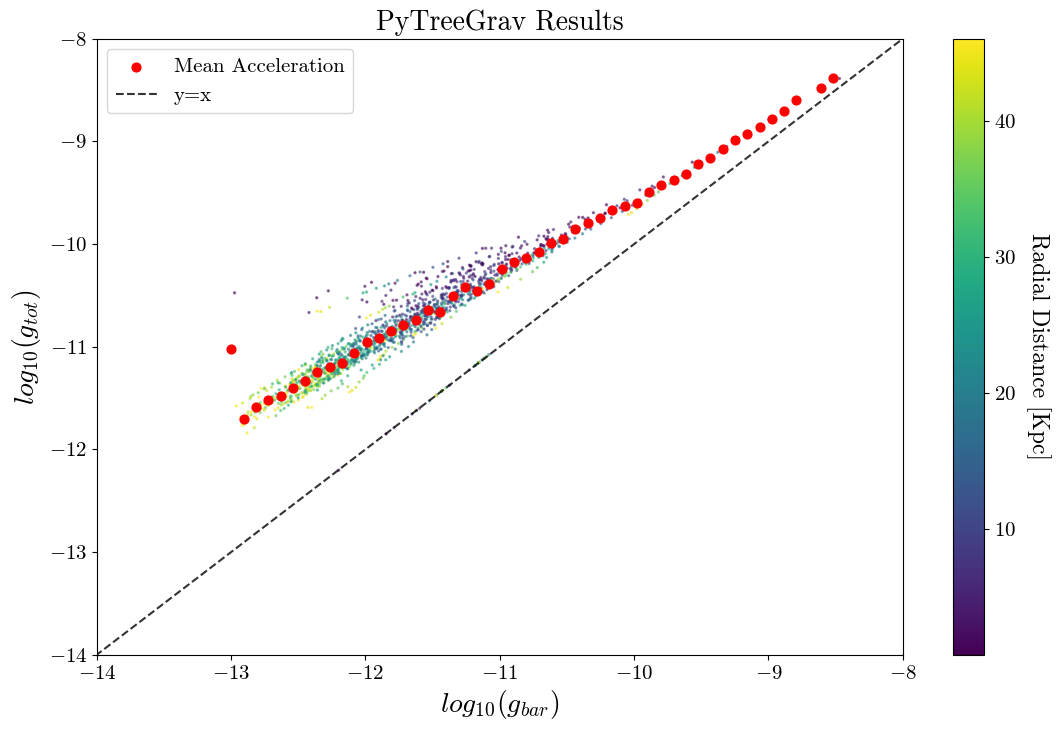

In [9]:
#PLOTTING PYTREEGRAV RESULTS
fig = plt.figure(figsize=(13, 8))

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


g_tot_all_tree = []
g_bar_all_tree = []

for gal in pytree_results:
  
    g_tot = pytree_results[gal][1]
    g_bar = pytree_results[gal][0]
    mean_r = pytree_results[gal][2]

    r_half = gas_r_half[gal == gal_indices][0]
    
    r_over_r_half = mean_r / r_half

    #MASK TO SAY HOW MANY MULTIPLES OF GAS_R_HALF YOU WANT TO GO OUT TO 

    r_mask = (r_over_r_half <= 5) & (r_over_r_half >= 0.2)

    g_tot = g_tot[r_mask]
    g_bar = g_bar[r_mask]
    mean_r = mean_r[r_mask]



    plt.scatter(np.log10(g_bar), np.log10(g_tot), s = 2, alpha = 0.5, c = mean_r)

    g_tot_all_tree = g_tot_all_tree + list(g_tot)
    g_bar_all_tree = g_bar_all_tree + list(g_bar)


g_tot_all_tree = np.array(g_tot_all_tree)
g_bar_all_tree = np.array(g_bar_all_tree)

print(len(g_tot_all_tree))
print(len(g_bar_all_tree))

mask = g_bar_all_tree > 0
g_tot_all_tree = g_tot_all_tree[mask]
g_bar_all_tree = g_bar_all_tree[mask]

print(len(g_tot_all_tree))
print(len(g_bar_all_tree))

mean, bins, bin_number = stats.binned_statistic(np.log10(g_bar_all_tree), np.log10(g_tot_all_tree), bins=100, statistic='mean')

bincenters = 0.5*(bins[1:]+bins[:-1])

plt.scatter(bincenters, mean, label = 'Mean Acceleration', color = 'red', s = 40)
#plt.plot(bincenters, mean, color = 'red', linewidth = 4)



x = np.linspace(-16, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x')


key = list(pytree_results.keys())[0]
colors = pytree_results[key][2]
points = np.array([np.log10(pytree_results[key][0]), np.log10(pytree_results[key][1])]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(colors)

cbar = fig.colorbar(lc, ax = plt.gca())
cbar.set_label("Radial Distance [Kpc]", rotation=270, labelpad=25, fontsize = 17)



plt.xlabel('$log_{10}(g_{bar})$', fontsize = 20)
plt.ylabel('$log_{10}(g_{tot})$', fontsize = 20)
plt.legend(prop={'size': 15})
plt.xlim(-14,-8)
plt.title('PyTreeGrav Results', fontsize = 20)
plt.ylim(-14,-8)

plt.show()

sample: 100%|██████████| 2500/2500 [00:04<00:00, 531.73it/s, 3 steps of size 1.01e+00. acc. prob=0.90]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.97      0.04      0.97      0.91      1.04   1747.95      1.00
     sigma      0.29      0.01      0.29      0.28      0.30   2004.80      1.00

Number of divergences: 0


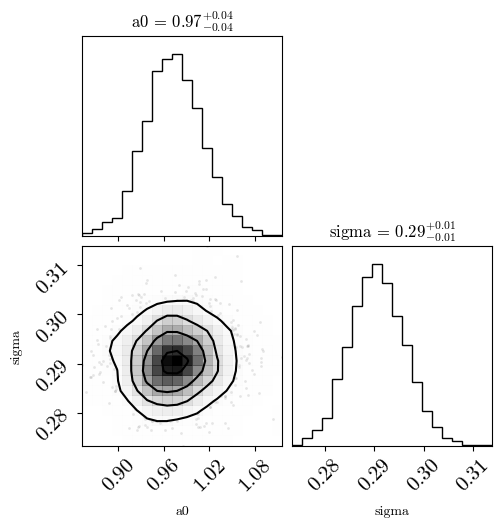

In [10]:
gbar, gtot = g_bar_all_tree, g_tot_all_tree


log_gbar = jnp.log10(gbar)
log_gtot = jnp.log10(gtot)


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    shape = 1
    
    # Prediction of y
    log_gtot_pred = jnp.log10(gbar*(1-jnp.exp(-(gbar/(a0*1e-10))**(shape/2)))**(-1/shape))  

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gtot_pred, sigma), obs=log_gtot)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=gbar, y=log_gtot)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True,
    smooth = 1,
)
plt.show()

a0: 0.9727552
sigma: 0.29051888


/tmp/ipykernel_473722/1205004169.py:30: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(g_bar_individual), np.log10(g_tot), alpha = 0.5, c = mean_r, s = 2)


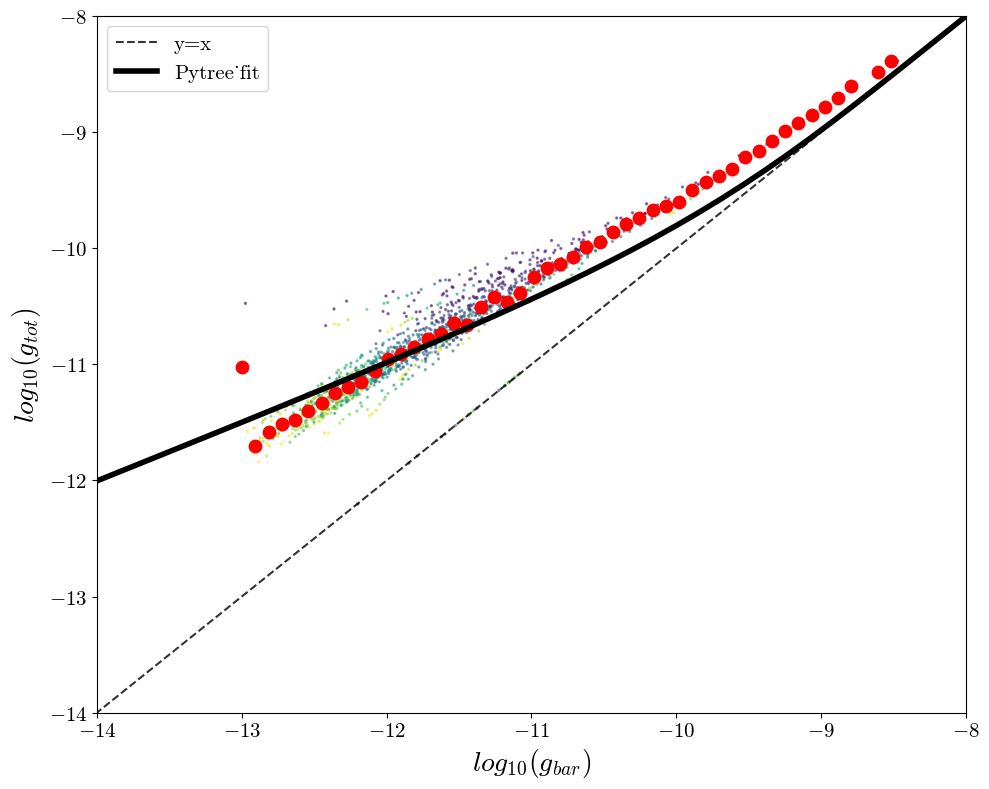

In [11]:
a0 = np.median(samples_array[:, 0])
sigma_pytree = np.median(samples_array[:, 1])

print('a0:', a0)
shape = 1
print('sigma:', sigma_pytree)

g_bar = np.logspace(-8, -14, 40)

log_g_tot_pred_pytree = np.log10(g_bar*(1-np.exp(-(g_bar/(a0*1e-10))**(shape/2)))**(-1/shape))

plt.figure(figsize=(10,8))

x = np.linspace(-15, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x')

for gal in pytree_results:
    g_tot = pytree_results[gal][1]
    g_bar_individual = pytree_results[gal][0]
    mean_r = pytree_results[gal][2]



    g_tot = g_tot[r_mask]
    g_bar_individual = g_bar_individual[r_mask]
    mean_r = mean_r[r_mask]


    plt.scatter(np.log10(g_bar_individual), np.log10(g_tot), alpha = 0.5, c = mean_r, s = 2)


#plt.scatter(np.log10(g_bar), log_g_tot_pred_pytree, color='black', label='Pytree_fit', s=80)
plt.plot(np.log10(g_bar), log_g_tot_pred_pytree, color='black', label='Pytree_fit', linewidth=4)


#plt.plot(bincenters, mean, color = 'red', linewidth = 4)
plt.scatter(bincenters, mean, color = 'red', s = 80)



#plt.scatter(bincenters, mean, color='red', label='Mean Acceleration', alpha = 0.8, marker = 'D')
plt.xlabel('$log_{10}(g_{bar})$', fontsize = 20)
plt.ylabel('$log_{10}(g_{tot})$', fontsize = 20)
plt.xlim(-14, -8)
plt.ylim(-14, -8)
plt.legend(prop = {'size': 15})
plt.tight_layout()
plt.show()

In [19]:
#Plotting RAR for all Galaxies

rar = defaultdict(list)

directory = '/mnt/users/darnej/MPhys/TNG-50/RAR_for_all_TNG'

files = glob.glob(os.path.join(directory, '*.csv'))

files.sort()

g_bar_all = []
g_rot_all = []
g_tot_all = []
mean_r_all = []
g_obs_all = []


for i in Chosen_galaxies:
    i = int(i)

    file = directory + '/results_for_' + str(i) + '.csv'
    csv = pd.read_csv(file, float_precision='round_trip')
    mean_acc_bar = csv['mean_acc_bar']
    mean_acc_obs = csv['mean_acc_obs']
    mean_r = csv['mean_r']
    total_mean_acc_bar = csv['total_mean_acc_bar']
    gal_number = int(i)


    try:
        g_obs = csv['g_obs']
    
    except KeyError:
        g_obs = np.zeros_like(mean_acc_bar)
        

    r_half = gas_r_half[gal_number == gal_indices][0]
    
    r_over_r_half = mean_r / r_half

    #MASK TO SAY HOW MANY MULTIPLES OF GAS_R_HALF YOU WANT TO GO OUT TO 

    r_mask = (r_over_r_half <= 2) & (r_over_r_half >= 0.1)

    mean_acc_bar = mean_acc_bar[r_mask]
    mean_acc_obs = mean_acc_obs[r_mask]
    mean_r = mean_r[r_mask]
    total_mean_acc_bar = total_mean_acc_bar[r_mask]
    g_obs = g_obs[r_mask]


    g_bar_all = g_bar_all + list(mean_acc_bar)
    g_rot_all = g_rot_all + list(mean_acc_obs)
    g_tot_all = g_tot_all + list(total_mean_acc_bar)
    mean_r_all = mean_r_all + list(mean_r)
    g_obs_all = g_obs_all + list(g_obs)



    rar[gal_number] = [mean_acc_bar, mean_acc_obs, mean_r, total_mean_acc_bar, g_obs]


g_tot_all = np.array(g_tot_all)
g_bar_all = np.array(g_bar_all)
g_rot_all = np.array(g_rot_all)
mean_r_all = np.array(mean_r_all)
g_obs_all = np.array(g_obs_all)

#The g bar values contains some 0's therefore we need to remove them to not get -inf when take log 10

print(len(g_bar_all))
print(len(g_rot_all))
print(len(g_tot_all))
print(len(g_obs_all))


g_tot_all = g_tot_all[g_bar_all > 0]
mean_r_all = mean_r_all[g_bar_all > 0]
g_rot_all = g_rot_all[g_bar_all > 0]
g_obs_all = g_obs_all[g_bar_all > 0]
g_bar_all = g_bar_all[g_bar_all > 0]



print(len(g_bar_all))
print(len(g_rot_all))
print(len(g_tot_all))
print(len(g_obs_all))


#Creating mean

mean_rot, bins_rot, bin_number = stats.binned_statistic(np.log10(g_bar_all), np.log10(g_rot_all), bins=100, statistic='mean')

bincenters_rot = 0.5*(bins_rot[1:]+bins_rot[:-1])

mean_tot, bins_tot, bin_number = stats.binned_statistic(np.log10(g_bar_all), np.log10(g_tot_all), bins=100, statistic='mean')

bincenters_tot = 0.5*(bins_tot[1:]+bins_tot[:-1])


mean_rar, bins_rar, bin_number = stats.binned_statistic(np.log10(g_bar_all), np.log10(g_obs_all), bins=100, statistic='mean')

bincenters_rar = 0.5*(bins_rar[1:]+bins_rar[:-1])


1683
1683
1683
1683
1678
1678
1678
1678


153


/tmp/ipykernel_2152524/2925227518.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


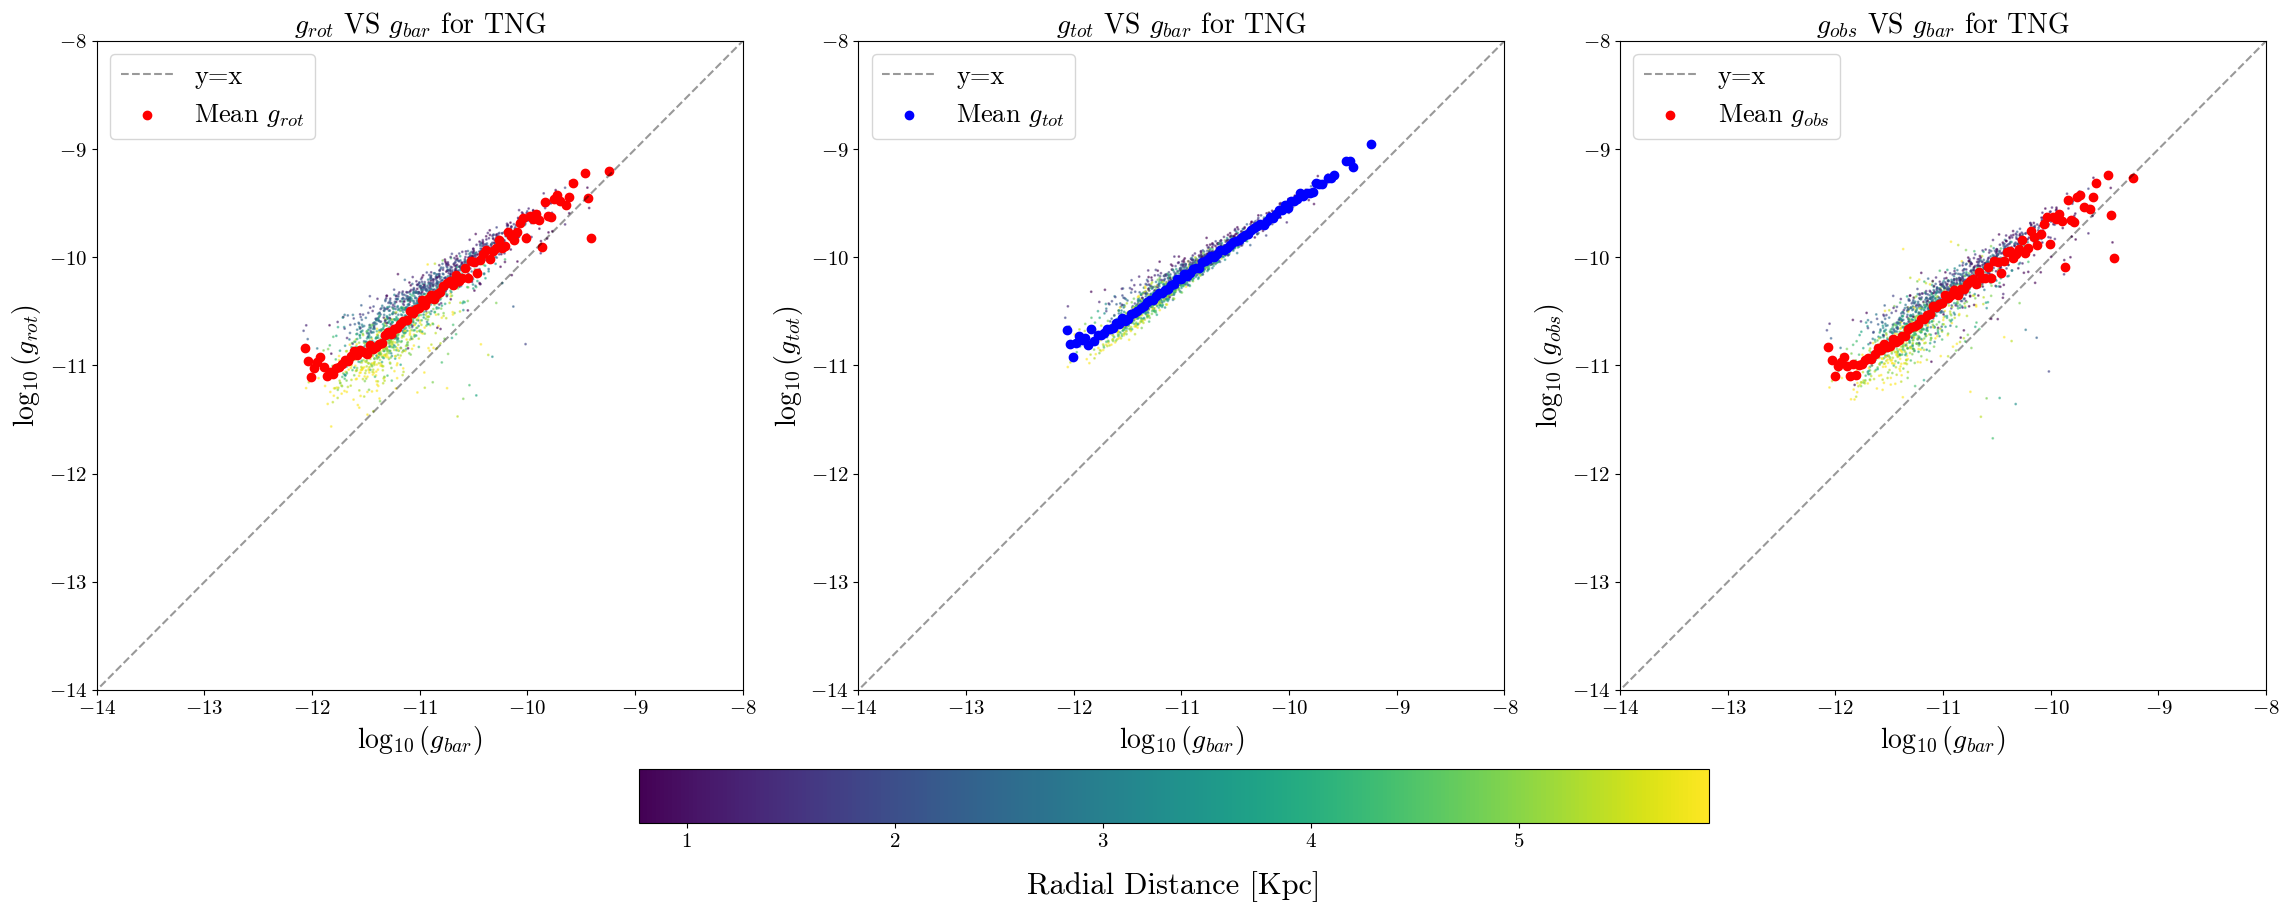

In [20]:
print(len(rar))

fig, ax = plt.subplots(1, 3, figsize = (23,10))
#fig.suptitle('RAR for all galaxies', fontsize = 30)

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size




for gal in rar:

    g_bar = rar[gal][0]
    g_rot = rar[gal][1]
    g_obs = rar[gal][4]


    ax[0].scatter(np.log10(g_bar), np.log10(g_rot), s = 1, alpha = 0.5, c = rar[gal][2])

    g_bar = rar[gal][0]
    g_tot = rar[gal][3]

    ax[1].scatter(np.log10(g_bar), np.log10(g_tot), s = 1, alpha = 0.5, c = rar[gal][2])

    ax[2].scatter(np.log10(g_bar), np.log10(g_obs), s = 1, alpha = 0.5, c = rar[gal][2])

    key = gal

x = np.linspace(-16, -8, 100)
y = x
ax[0].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4, label = 'y=x')
ax[1].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4, label = 'y=x')  
ax[2].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4, label = 'y=x')


ax[0].scatter(bincenters_rot, mean_rot, label = 'Mean $g_{rot}$', color = 'red')

ax[0].set_xlabel('$\log_{10}({g_{bar}})$', fontsize = 20)
ax[0].set_ylabel('$\log_{10}({g_{rot}})$', fontsize = 20)
ax[0].set_title('$g_{rot}$ VS $g_{bar}$ for TNG', fontsize = 20)
ax[0].set_xlim(-14, -8)
ax[0].set_ylim(-14,-8)


ax[1].scatter(bincenters_tot, mean_tot, color = 'blue', label = 'Mean $g_{tot}$')

ax[1].set_xlabel('$\log_{10}({g_{bar}})$', fontsize = 20)
ax[1].set_ylabel('$\log_{10}({g_{tot}})$', fontsize = 20)
ax[1].set_title('$g_{tot}$ VS $g_{bar}$ for TNG', fontsize = 20)
ax[1].set_xlim(-14, -8)
ax[1].set_ylim(-14,-8)


ax[2].scatter(bincenters_rar, mean_rar, color = 'red', label = 'Mean $g_{obs}$')

ax[2].set_xlabel('$\log_{10}({g_{bar}})$', fontsize = 20)
ax[2].set_ylabel('$\log_{10}({g_{obs}})$', fontsize = 20)
ax[2].set_title('$g_{obs}$ VS $g_{bar}$ for TNG', fontsize = 20)
ax[2].set_xlim(-14, -8)
ax[2].set_ylim(-14,-8)



colors = rar[key][2]
points = np.array([np.log10(rar[key][0]), np.log10(rar[key][1])]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(colors)


cbar = fig.colorbar(lc, ax=ax[:], location = 'bottom', shrink = 0.6, pad = -0.44)
cbar.set_label("Radial Distance [Kpc]", labelpad=15, fontsize = 22)

actual_g_bar = np.linspace(1e-8, 1e-14, 100)
actual_g_obs = actual_g_bar/2 + np.sqrt((actual_g_bar**2)/4 + actual_g_bar*1.6e-10)

actual_g_tot = actual_g_bar/(1-np.exp(-np.sqrt(actual_g_bar/1.2e-10)))

#ax[0].plot(np.log10(actual_g_bar), np.log10(actual_g_obs), label = 'Theoretical', color = 'black')
#ax[1].plot(np.log10(actual_g_bar), np.log10(actual_g_tot), label = 'Theoretical', color = 'black')

ax[0].legend(prop={'size': 19})
ax[1].legend(prop={'size': 19})
ax[2].legend(prop={'size': 19})
plt.tight_layout()
plt.show()

sample: 100%|██████████| 2500/2500 [00:05<00:00, 436.73it/s, 3 steps of size 9.58e-01. acc. prob=0.89] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.96      0.03      0.96      0.92      1.00   2274.88      1.00
     sigma      0.19      0.00      0.19      0.19      0.20   1837.40      1.00

Number of divergences: 0


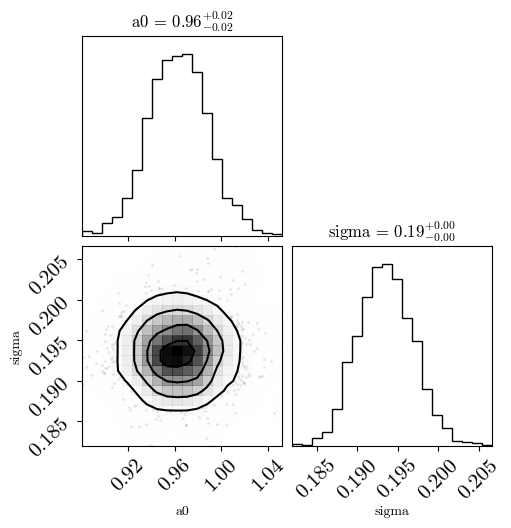

In [21]:


gbar, gobs = g_bar_all, g_obs_all


log_gbar = jnp.log10(gbar)
log_gobs = jnp.log10(gobs)



def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    shape = 1
    
    # Prediction of y
    log_gobs_pred = jnp.log10(gbar*(1-jnp.exp(-(gbar/(a0*1e-10))**(shape/2)))**(-1/shape))   # Add RAR formula

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gobs_pred, sigma), obs=log_gobs)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=gbar, y=log_gobs)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array_obs = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array_obs,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True,
    smooth = 1,
)
plt.show()

a0: 0.96321124
shape: 1
sigma: 0.19350436


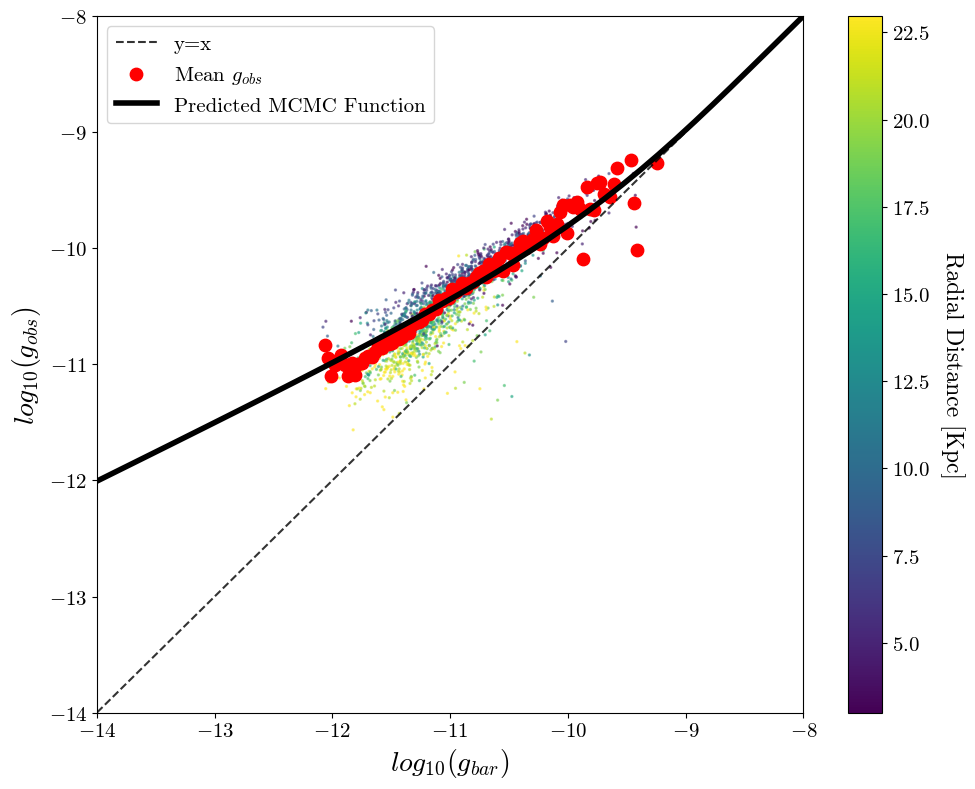

In [22]:

a0 = np.median(samples_array_obs[:, 0])
shape = 1
sigma_obs = np.median(samples_array_obs[:, 1])

print('a0:', a0)
print('shape:', shape)
print('sigma:', sigma_obs)

g_bar = np.logspace(-8, -14, 40)

log_g_obs_pred = np.log10(g_bar*(1-np.exp(-(g_bar/(a0*1e-10))**(shape/2)))**(-1/shape))  



plt.figure(figsize=(10,8))

x = np.linspace(-15, -8, 100)
y = x



for gal in rar:
    g_obs = rar[gal][1]
    g_bar_individual = rar[gal][0]
    mean_r = rar[gal][2]

    plt.scatter(np.log10(g_bar_individual), np.log10(g_obs), alpha = 0.5, c = mean_r, s = 2)

plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x')

#plt.plot(bincenters_rar, mean_rar, color = 'red', linewidth = 4, label = 'Mean $g_{obs}$')
plt.scatter(bincenters_rar, mean_rar, color = 'red', s = 80, label = 'Mean $g_{obs}$')

#plt.scatter(np.log10(g_bar), log_g_obs_pred, color='black', label='Predicted MCMC Function', s = 80)
plt.plot(np.log10(g_bar), log_g_obs_pred, color='black', label='Predicted MCMC Function', linewidth = 4)

key = list(rar.keys())[0]
colors = rar[key][2]
points = np.array([np.log10(rar[key][0]), np.log10(rar[key][1])]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(colors)

cbar = fig.colorbar(lc, ax = plt.gca())
cbar.set_label("Radial Distance [Kpc]", rotation=270, labelpad=25, fontsize = 17)



plt.xlabel('$log_{10}(g_{bar})$', fontsize = 20)
plt.ylabel('$log_{10}(g_{obs})$', fontsize = 20)
plt.xlim(-14, -8)
plt.ylim(-14, -8)
plt.legend(prop = {'size': 15})
plt.tight_layout()
plt.show()

sample: 100%|██████████| 2500/2500 [00:05<00:00, 445.38it/s, 3 steps of size 1.09e+00. acc. prob=0.89]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      3.29      0.04      3.29      3.22      3.35   2229.54      1.00
     sigma      0.10      0.00      0.10      0.10      0.10   2058.44      1.00

Number of divergences: 0


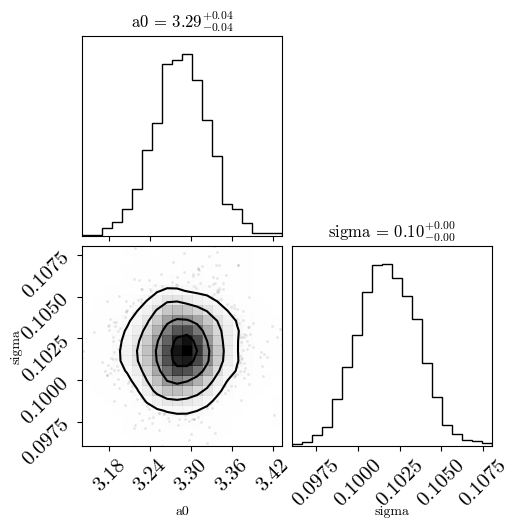

In [23]:
gbar, gtot = g_bar_all, g_tot_all

log_gbar = jnp.log10(gbar)
log_gtot = jnp.log10(gtot)


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    shape = 1
    
    # Prediction of y
    log_gtot_pred = jnp.log10(gbar*(1-jnp.exp(-(gbar/(a0*1e-10))**(shape/2)))**(-1/shape))   # Add RAR formula

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gtot_pred, sigma), obs=log_gtot)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=gbar, y=log_gtot)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array_tot = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array_tot,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True,
    smooth = 1
)
plt.show()

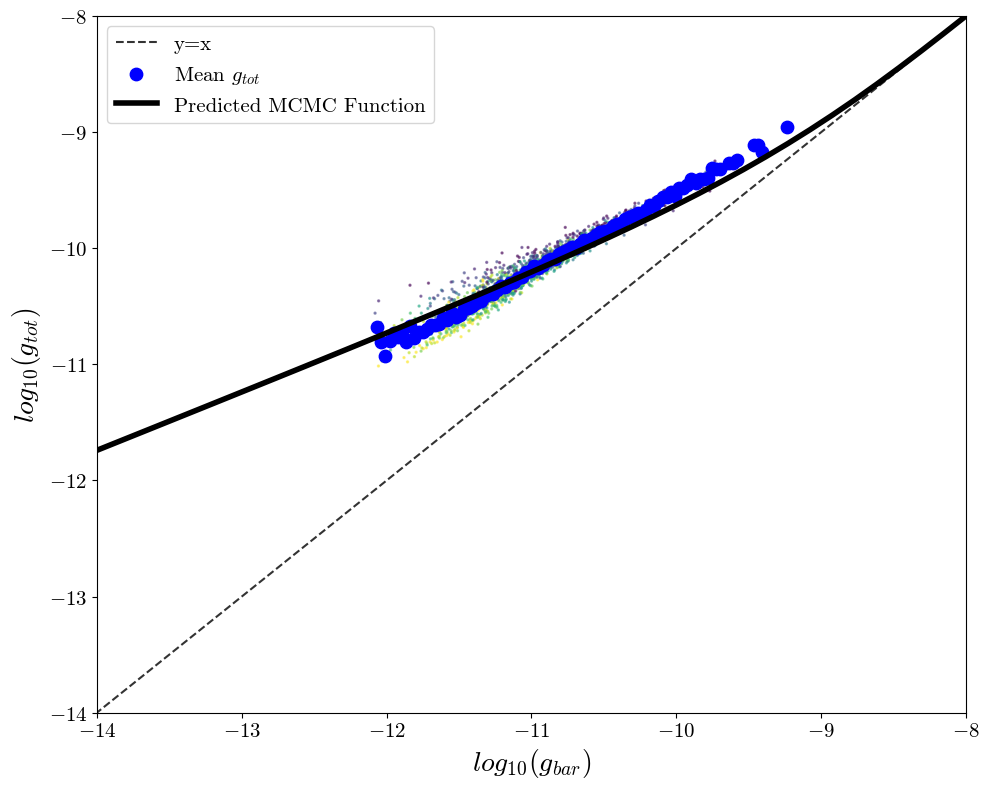

In [24]:

a0 = np.median(samples_array_tot[:, 0])
shape = 1
sigma_tot = np.median(samples_array_tot[:, 1])

g_bar = np.logspace(-8, -14, 40)

log_g_tot_pred = np.log10(g_bar*(1-np.exp(-(g_bar/(a0*1e-10))**(shape/2)))**(-1/shape))  

plt.figure(figsize=(10,8))


x = np.linspace(-15, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x')



for gal in rar:
    g_tot = rar[gal][3]
    g_bar_individual = rar[gal][0]
    mean_r = rar[gal][2]

    plt.scatter(np.log10(g_bar_individual), np.log10(g_tot), alpha = 0.5, c = mean_r, s = 2)

#plt.plot(bincenters_tot, mean_tot, color = 'blue', linewidth = 4, label = 'Mean $g_{tot}$')
plt.scatter(bincenters_tot, mean_tot, color = 'blue', s = 80, label = 'Mean $g_{tot}$')


#plt.scatter(np.log10(g_bar), log_g_tot_pred, color='black', label='Predicted MCMC Function', s = 80)
plt.plot(np.log10(g_bar), log_g_tot_pred, color='black', label='Predicted MCMC Function', linewidth = 4)


plt.xlabel('$log_{10}(g_{bar})$', fontsize = 20)
plt.ylabel('$log_{10}(g_{tot})$', fontsize = 20)
plt.xlim(-14, -8)
plt.ylim(-14, -8)
plt.legend(prop = {'size': 15})
plt.tight_layout()
plt.show()

153


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/users/darnej/MPhys/SPARC_RAR.csv'

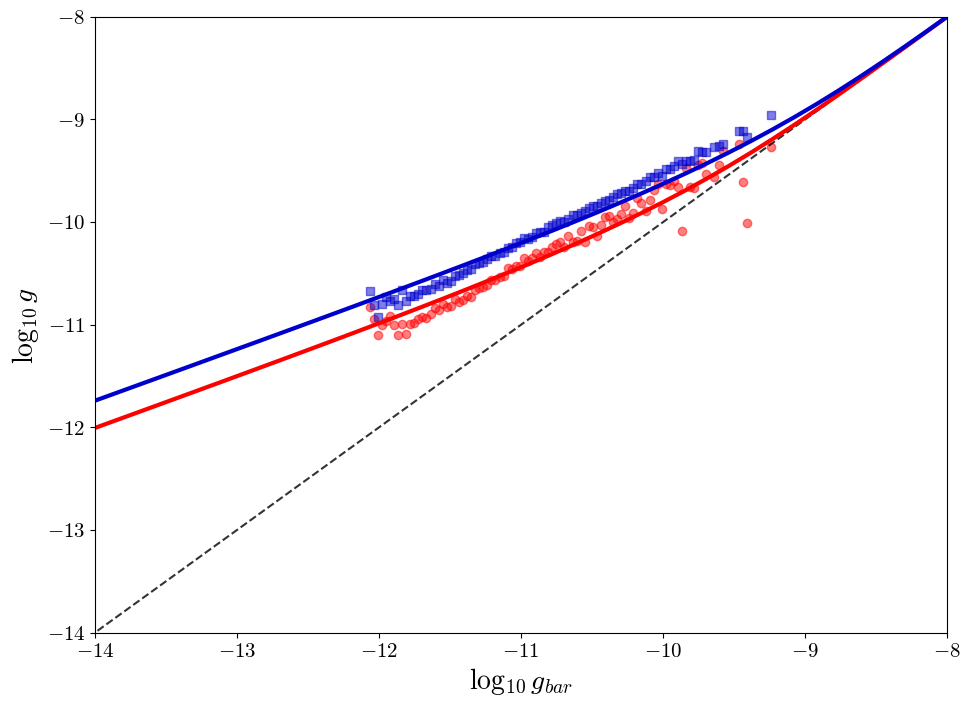

In [25]:
print(len(rar))

fig, ax = plt.subplots(figsize = (11,8))


plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size




# for gal in rar:

#     g_bar = rar[gal][0]
#     g_obs = rar[gal][1]

#     plt.scatter(np.log10(g_bar), np.log10(g_obs), s = 1, alpha = 0.3, c = rar[gal][2])

#     g_bar = rar[gal][0]
#     g_tot = rar[gal][3]

#     plt.scatter(np.log10(g_bar), np.log10(g_tot), s = 1, alpha = 0.3, c = rar[gal][2])


x = np.linspace(-16, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.8, label = 'y=x') 

g_bar = np.logspace(-8, -14, 40)

plt.scatter(bincenters_rar, mean_rar, label = 'Mean $g_{obs}$', color = 'red', alpha = 0.5)
plt.plot(np.log10(g_bar), log_g_obs_pred, color='red', linewidth = 3)


plt.xlabel('$\log_{10}{g_{bar}}$', fontsize = 20)
plt.ylabel('$\log_{10}{g}$', fontsize = 20)
plt.xlim(-14, -8)
plt.ylim(-14,-8)


plt.scatter(bincenters_tot, mean_tot, color = 'mediumblue', label = 'Mean $g_{tot}$', alpha = 0.5, marker = ',')
plt.plot(np.log10(g_bar), log_g_tot_pred, color='mediumblue', linewidth = 3)


# colors = rar[1][2]
# points = np.array([np.log10(rar[1][0]), np.log10(rar[1][1])]).T.reshape(-1, 1, 2)
# segments = np.concatenate([points[:-1], points[1:]], axis=1)
# norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
# lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
# lc.set_array(colors)

# cbar = fig.colorbar(lc, ax=ax)
# cbar.set_label("Radial Distance [Kpc]", rotation=270, labelpad=25, fontsize = 15)


SPARC_csv = pd.read_csv('/mnt/users/darnej/MPhys/SPARC_RAR.csv', float_precision='round_trip')

SPARC_g_bar = np.array(SPARC_csv.iloc[:, 0])
SPARC_g_obs = np.array(SPARC_csv.iloc[:, 1])
SPARC_std = np.array(SPARC_csv.iloc[:, 2])

#plt.errorbar(SPARC_g_bar, SPARC_g_obs, yerr = SPARC_std, fmt = 'o', color = 'black', label = 'SPARC Data', ms = 8)


plt.legend(prop={'size': 16})
plt.tight_layout()
plt.show()



NameError: name 'g_bar_all_tree' is not defined

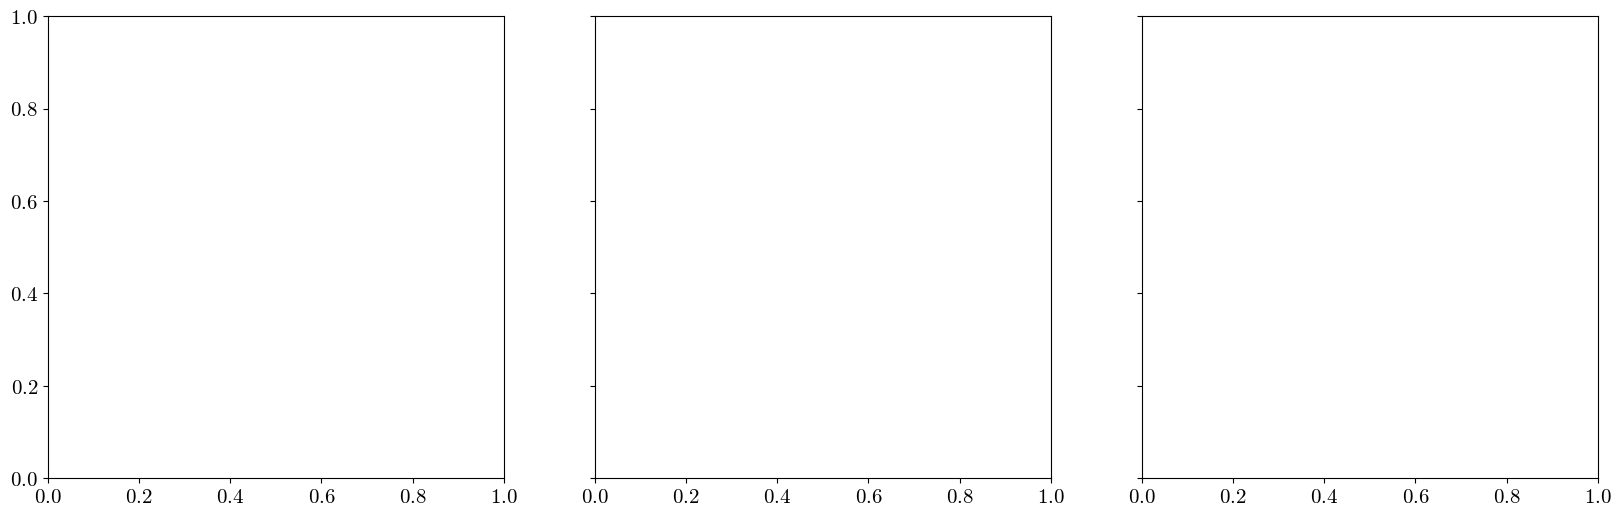

In [26]:
fig, ax = plt.subplots(1, 3, figsize = (20,6), sharey=True, sharex=True)
#plt.suptitle('Comparison of PyTreeGrav and RAR for all galaxies', fontsize = 20)

print(len(g_bar_all_tree))
print(len(g_obs_all))



ax[0].scatter(bincenters, mean, color = 'blue', label = 'PyTreeGrav')
ax[1].scatter(bincenters_tot, mean_tot, color = 'red', label = 'Extracted RAR')
ax[2].scatter(bincenters, mean, color = 'blue', alpha = 0.5, label = 'PyTreeGrav', s = 15)
ax[2].scatter(bincenters_tot, mean_tot, color = 'red', alpha = 0.5, label = 'Extracted RAR', s = 15)


x_fit = np.linspace(-19, -5, 100)
y_fit = x_fit


ax[0].plot(x_fit, y_fit, linestyle = 'dashed', color = 'r', alpha = 0.6)
ax[1].plot(x_fit, y_fit, linestyle = 'dashed', color = 'r', alpha = 0.6)
ax[2].plot(x_fit, y_fit, linestyle = 'dashed', color = 'r', alpha = 0.6)


SPARC_csv = pd.read_csv('/mnt/users/darnej/MPhys/SPARC_RAR.csv', float_precision='round_trip')

SPARC_g_bar = np.array(SPARC_csv.iloc[:, 0])
SPARC_g_obs = np.array(SPARC_csv.iloc[:, 1])
SPARC_std = np.array(SPARC_csv.iloc[:, 2])

#ax[2].errorbar(SPARC_g_bar, SPARC_g_obs, yerr = SPARC_std, fmt = 'o', color = 'black', label = 'SPARC mean')


ax[0].set_xlabel('$log_{10}{g_{bar}}$', fontsize = 16)
ax[0].set_ylabel('$log_{10}{g_{total}}$', fontsize = 16)
ax[0].legend(prop={'size': 15})
ax[1].set_xlabel('$log_{10}{g_{bar}}$', fontsize = 16)
ax[1].set_ylabel('$log_{10}{g_{total}}$', fontsize = 16)
ax[1].legend(prop={'size': 15})
ax[2].set_xlabel('$log_{10}{g_{bar}}$', fontsize = 16)
ax[2].set_ylabel('$log_{10}{g_{total}}$', fontsize = 16)
ax[2].set_xlim(-12.5, -8)
ax[2].set_ylim(-12.5, -8)
ax[2].legend(prop={'size': 15})
plt.tight_layout()
plt.show()

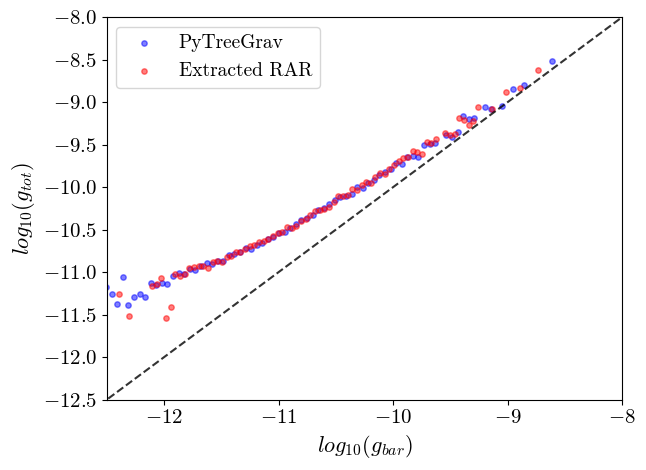

In [48]:

plt.scatter(bincenters, mean, color = 'blue', alpha = 0.5, label = 'PyTreeGrav', s = 15)
plt.scatter(bincenters_tot, mean_tot, color = 'red', alpha = 0.5, label = 'Extracted RAR', s = 15)


x_fit = np.linspace(-19, -5, 100)
y_fit = x_fit

plt.plot(x_fit, y_fit, linestyle = 'dashed', color = 'black', alpha = 0.8)


plt.xlabel('$log_{10}(g_{bar})$', fontsize = 16)
plt.ylabel('$log_{10}(g_{tot})$', fontsize = 16)
plt.legend(prop={'size': 14})
plt.xlim(-12.5, -8)
plt.ylim(-12.5, -8)
plt.tight_layout()
plt.show()

sample: 100%|██████████| 2500/2500 [00:03<00:00, 651.46it/s, 3 steps of size 8.07e-01. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      1.16      0.02      1.16      1.13      1.19   1825.77      1.00
     sigma      0.13      0.00      0.13      0.13      0.14   1465.15      1.00

Number of divergences: 0


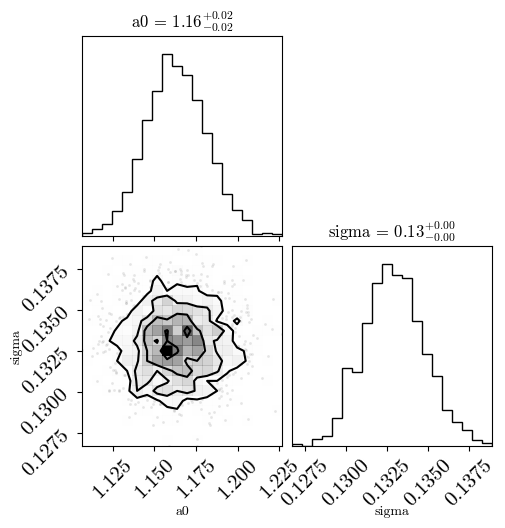

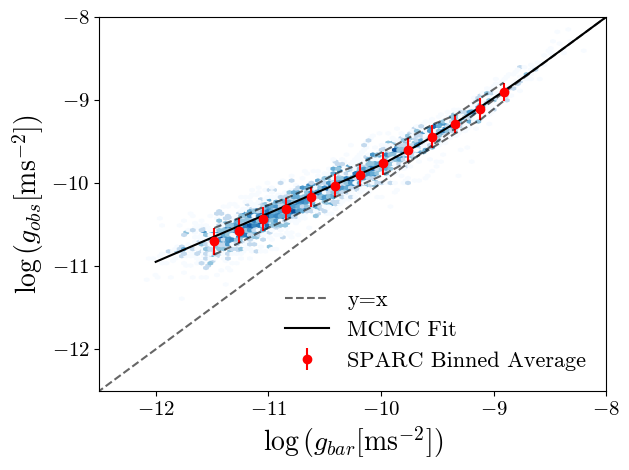

In [49]:
# Read space-separated data
all_SPARC_data = pd.read_csv('SPARC_ALL_DATA_RAR.csv', float_precision='round_trip')

SPARC_all_g_bar_log = np.array(all_SPARC_data.iloc[:, 0])
SPARC_g_bar_error_log = np.array(all_SPARC_data.iloc[:, 1])
SPARC_all_g_obs_log = np.array(all_SPARC_data.iloc[:, 2])
SPARC_g_obs_error_log = np.array(all_SPARC_data.iloc[:, 3])

SPARC_g_bar = 10**SPARC_all_g_bar_log
SPARC_g_obs = 10**SPARC_all_g_obs_log


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    
    # Prediction of y
    log_gobs_pred = jnp.log10(SPARC_g_bar/(1-jnp.exp(-jnp.sqrt(SPARC_g_bar/(a0*1e-10)))))  # Add RAR formula

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gobs_pred, sigma), obs=SPARC_all_g_obs_log)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=SPARC_g_bar, y=SPARC_all_g_obs_log)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array_sparc = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array_sparc,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True
)
plt.show()

a0_sparc = np.median(samples_array_sparc[:, 0])

#plt.errorbar(SPARC_all_g_bar, SPARC_all_g_obs, yerr = SPARC_g_obs_error, xerr = SPARC_g_bar_error, label = 'SPARC Data', alpha = 0.05)
plt.hexbin(SPARC_all_g_bar_log, SPARC_all_g_obs_log, cmap='Blues', mincnt = 1, bins = 'log')
SPARC_csv = pd.read_csv('/mnt/users/darnej/MPhys/SPARC_RAR.csv', float_precision='round_trip')

SPARC_g_bar_mean = np.array(SPARC_csv.iloc[:, 0])
SPARC_g_obs_mean = np.array(SPARC_csv.iloc[:, 1])
SPARC_std_mean = np.array(SPARC_csv.iloc[:, 2])

plt.errorbar(SPARC_g_bar_mean, SPARC_g_obs_mean, yerr = SPARC_std_mean, fmt = 'o', color = 'red', label = 'SPARC Binned Average')

x = np.linspace(-16, -8, 100)
y = x
plt.plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.6, label = 'y=x') 

gbar = np.linspace(1e-8, 1e-12, 100)

plt.plot(np.log10(gbar), np.log10(gbar/(1-np.exp(-np.sqrt(gbar/(a0_sparc*1e-10))))), label = 'MCMC Fit', color = 'black')

plt.plot(SPARC_g_bar_mean, SPARC_g_obs_mean + SPARC_std_mean, linestyle = 'dashed', color = 'black', alpha = 0.6)
plt.plot(SPARC_g_bar_mean, SPARC_g_obs_mean - SPARC_std_mean, linestyle = 'dashed', color = 'black', alpha = 0.6)


plt.xlabel('$\log{(g_{bar}[\mathrm{ms^{-2}}])}$', fontsize = 20)
plt.ylabel('$\log{(g_{obs}[\mathrm{ms^{-2}}])}$', fontsize = 20)
plt.xlim(-12.5, -8)
plt.ylim(-12.5,-8)

plt.tight_layout()
plt.legend(prop={'size': 16}, frameon = False)
plt.show()


sample: 100%|██████████| 2500/2500 [00:04<00:00, 521.75it/s, 3 steps of size 9.27e-01. acc. prob=0.91] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        a0      0.40      0.01      0.40      0.38      0.42   2159.70      1.00
     sigma      0.20      0.00      0.20      0.19      0.20   1657.68      1.00

Number of divergences: 0


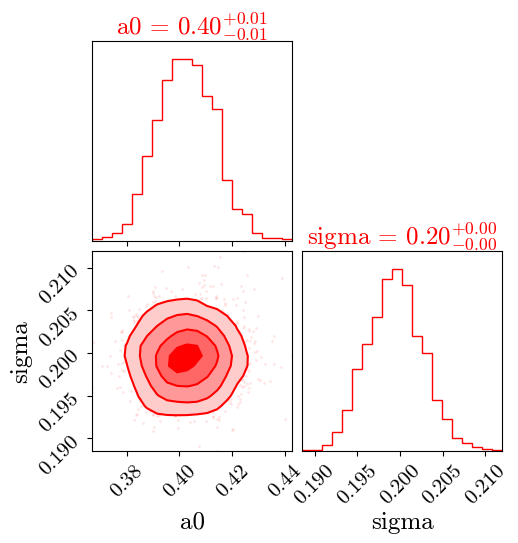

In [53]:
g_obs_plot_all = []
g_bar_tree_plot_all = []

for gal in rar:
    g_obs = rar[gal][1]
    g_bar_tree = pytree_results[gal][0]

    g_bar_tree = g_bar_tree[r_mask]

    mask = (g_obs > 0) & (g_bar_tree > 0)

    g_obs_plot = g_obs[mask]
    g_bar_tree_plot = g_bar_tree[mask]

    g_obs_plot_all = g_obs_plot_all + list(g_obs_plot)
    g_bar_tree_plot_all = g_bar_tree_plot_all + list(g_bar_tree_plot)


g_bar_tree_plot_all = np.array(g_bar_tree_plot_all)
g_obs_plot_all = np.array(g_obs_plot_all)

gbar, gobs = g_bar_tree_plot_all, g_obs_plot_all

log_gbar = jnp.log10(gbar)
log_gobs = jnp.log10(gobs)


def model(x=None, y=None):

    a0 = numpyro.sample("a0", dist.Uniform(0, 5))
    sigma = numpyro.sample("sigma", dist.Uniform(0, 5))
    shape = 1
    
    # Prediction of y
    log_gobs_pred = jnp.log10(gbar*(1-jnp.exp(-(gbar/(a0*1e-10))**(shape/2)))**(-1/shape))    # Add RAR formula

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(log_gobs_pred, sigma), obs=log_gobs)

# Run MCMC
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(kernel, num_warmup=500, num_samples=2000)
mcmc.run(rng_key_, x=gbar, y=log_gobs)

mcmc.print_summary()
samples = mcmc.get_samples()
res = az.from_numpyro(mcmc)

# Extract posterior samples as a NumPy array
samples_array_mixed = np.array([res.posterior[var].values.flatten() for var in res.posterior.keys()]).T


# Corner plot
fig = corner.corner(
    samples_array_mixed,
    labels=list(res.posterior.keys()),  # Ensure correct variable names
    show_titles=True,
    smooth = 1,
    color = 'red',
    fill_contours=True,
    title_kwargs={"fontsize": 18, "color": "red"},
    label_kwargs={"fontsize": 18}
)
plt.show()


a0 = np.median(samples_array_mixed[:, 0])
shape = 1
sigma_mixed = np.median(samples_array_mixed[:, 1])

g_bar = np.logspace(-8, -14, 40)

log_g_mixed_pred = np.log10(g_bar*(1-np.exp(-(g_bar/(a0*1e-10))**(shape/2)))**(-1/shape))  

/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_991229/1539140498.py:41: RuntimeWarning: divide by zero encountered in log10
  ax[1].scatter(np.log10(g_bar_tree), np.log10(g_tot_tree), s = 1, alpha = 0.5, c = mean_r)
/tmp/ipykernel_991229/1539140498.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


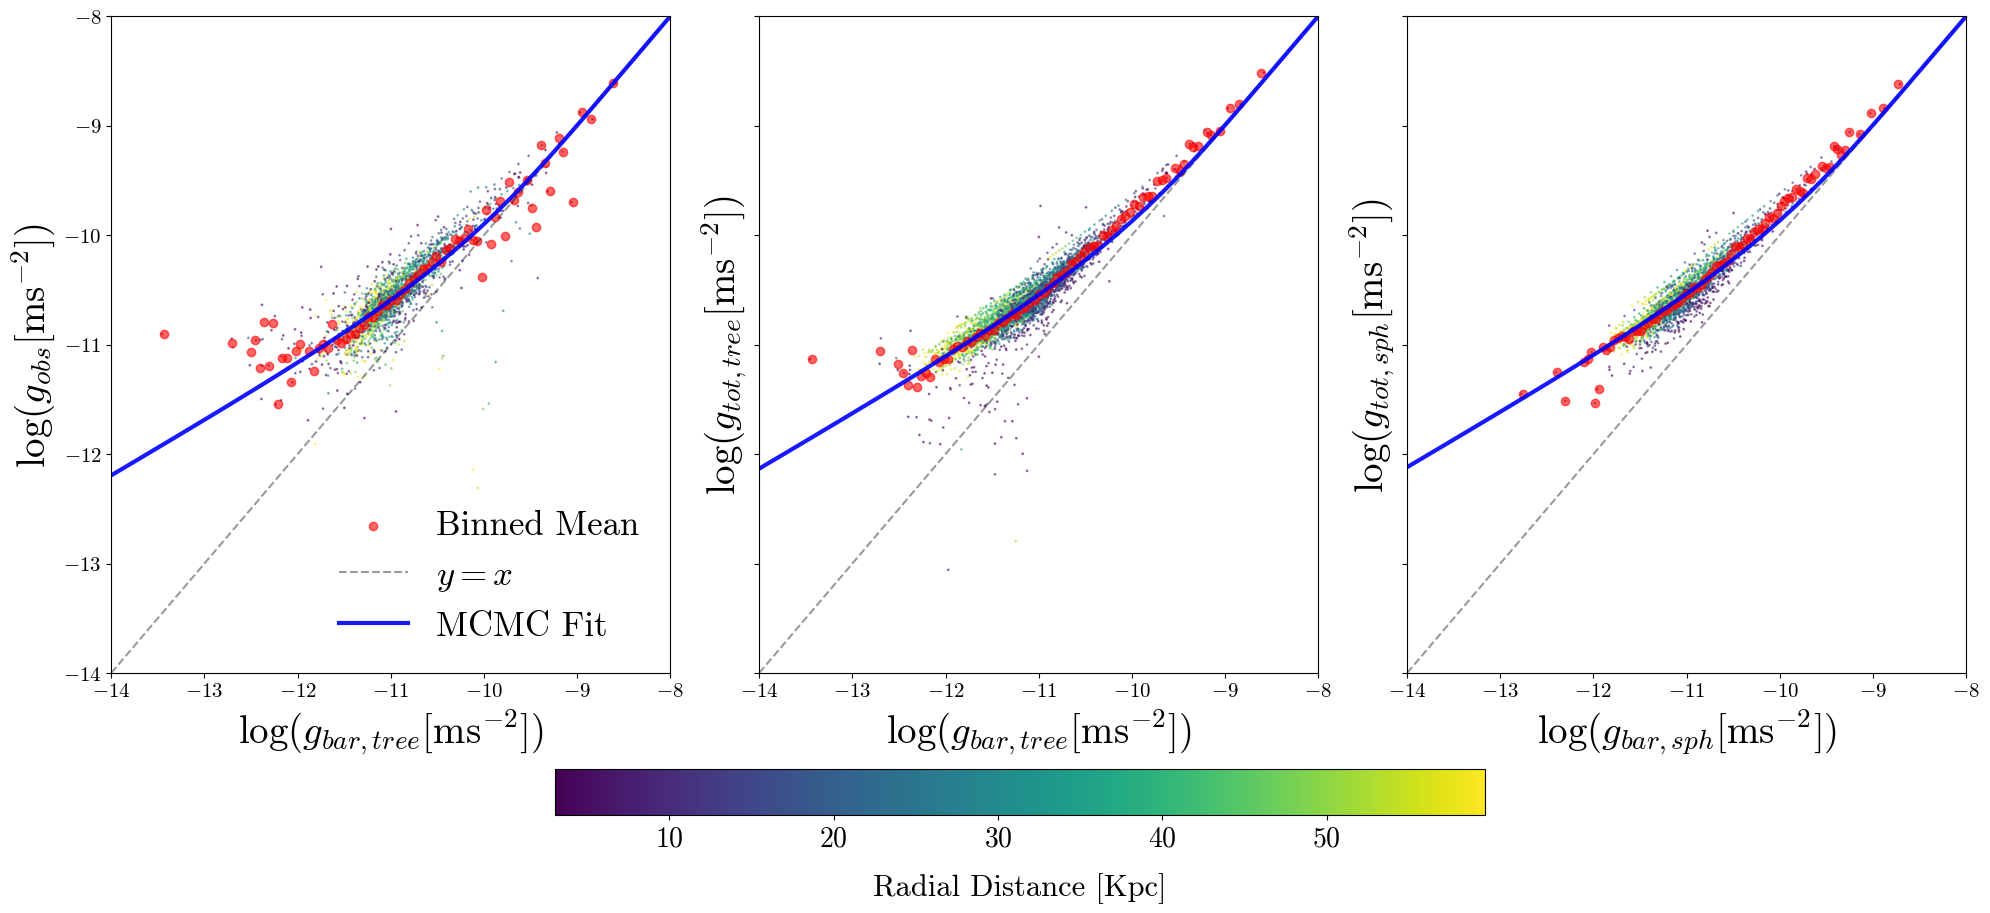

In [ ]:
fig, ax = plt.subplots(1, 3, figsize = (20,10), sharey = True, sharex = True)


plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 20  # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 20   # Increase y-axis tick font size

x = np.linspace(-14, -8, 100)
y = x

g_obs_plot_all = []
g_bar_tree_plot_all = []

for gal in rar:

    g_bar = rar[gal][0]
    g_obs = rar[gal][1]
    g_tot = rar[gal][3]

    g_tot_tree = pytree_results[gal][1]
    g_bar_tree = pytree_results[gal][0]
    mean_r = pytree_results[gal][2]

    g_bar_tree = g_bar_tree[r_mask]
    mean_r = mean_r[r_mask]
    g_tot_tree = g_tot_tree[r_mask]

    mask = (g_obs > 0) & (g_bar_tree > 0)

    g_obs_plot = g_obs[mask]
    g_bar_tree_plot = g_bar_tree[mask]
    mean_r_plot = mean_r[mask]

    g_obs_plot_all = g_obs_plot_all + list(g_obs_plot)
    g_bar_tree_plot_all = g_bar_tree_plot_all + list(g_bar_tree_plot)

    ax[0].scatter(np.log10(g_bar_tree_plot), np.log10(g_obs_plot), s = 1, alpha = 0.5, c = mean_r_plot)
    ax[2].scatter(np.log10(g_bar), np.log10(g_tot), s = 1, alpha = 0.5, c = rar[gal][2])
    ax[1].scatter(np.log10(g_bar_tree), np.log10(g_tot_tree), s = 1, alpha = 0.5, c = mean_r)



mean_mixed, bins_mixed, bin_number = stats.binned_statistic(np.log10(g_bar_tree_plot_all), np.log10(g_obs_plot_all), bins=100, statistic='mean')

bincenters_mixed = 0.5*(bins_mixed[1:]+bins_mixed[:-1])


ax[0].scatter(bincenters_mixed, mean_mixed, color = 'red', alpha = 0.6, label = 'Binned Mean')
ax[0].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4, label='$y=x$')
ax[0].set_xlabel('$\log({g_{bar,tree}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[0].set_ylabel('$\log({g_{obs}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[0].set_xlim(-14, -8)
ax[0].set_ylim(-14,-8)

ax[2].scatter(bincenters_tot, mean_tot, color = 'red', alpha = 0.6)
ax[2].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4)
ax[2].set_xlabel('$\log({g_{bar,sph}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[2].set_ylabel('$\log({g_{tot,sph}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[2].set_xlim(-14, -8)
ax[2].set_ylim(-14,-8)

ax[1].scatter(bincenters, mean, color = 'red', alpha = 0.6)
ax[1].plot(x, y, linestyle = 'dashed', color = 'black', alpha = 0.4)
ax[1].set_xlabel('$\log({g_{bar,tree}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[1].set_ylabel('$\log({g_{tot,tree}[\mathrm{ms^{-2}}]})$', fontsize = 28)
ax[1].set_xlim(-14, -8)
ax[1].set_ylim(-14,-8)


colors = rar[1][2]
points = np.array([np.log10(rar[1][0]), np.log10(rar[1][1])]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(np.array(colors).min(), np.array(colors).max())
lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(colors)

cbar = fig.colorbar(lc, ax=ax[:], location = 'bottom', shrink = 0.6, pad = -0.44)
cbar.set_label("Radial Distance [Kpc]", labelpad=15, fontsize = 22)




g_bar = np.logspace(-8, -14, 40)

ax[0].plot(np.log10(g_bar), log_g_mixed_pred, color='blue', linewidth = 3, alpha = 0.9, label = "MCMC Fit")

ax[2].plot(np.log10(g_bar), log_g_tot_pred, color='blue', linewidth = 3, alpha = 0.9)

ax[1].plot(np.log10(g_bar), log_g_tot_pred_pytree, color='blue', linewidth = 3, alpha = 0.9)

plt.tight_layout()
ax[0].legend(prop={'size': 25}, loc = 'lower right', frameon = False, fontsize = 30)
plt.show()

['/mnt/users/darnej/MPhys/samples_53_scatter_EFE0_rar.npy', '/mnt/users/darnej/MPhys/labels_53_scatter_EFE0_rar.npy']


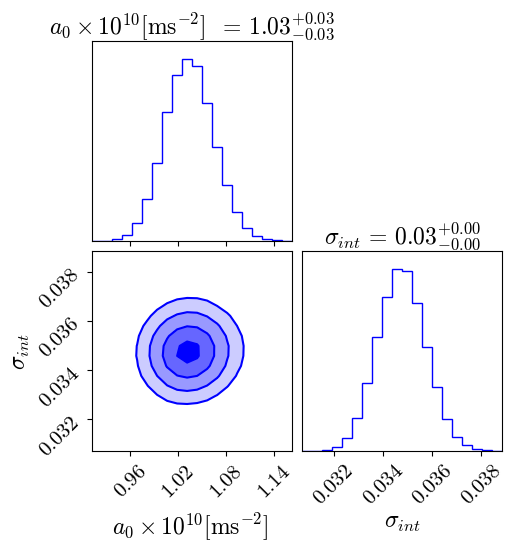

In [ ]:
#OBSERVED SPARC SCATTER


plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


directory = '/mnt/users/darnej/MPhys/'

files = glob.glob(os.path.join(directory, '*.npy'))

print(files)

samples = files[0]
labels = files[1]

labels = np.load(labels)

samples = np.load(samples)

a0_index = np.where(labels == 'a0')[0][0]

scatter_index = np.where(labels == 'scatter')[0][0]

a0 = samples[:, a0_index]

scatter = samples[:, scatter_index]

samples_SPARC = np.column_stack((a0, scatter))

fig = corner.corner(samples_SPARC, 
                      labels=[r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$ ', '$\sigma_{int}$'],
                      show_titles=True,
                      title_kwargs={"fontsize": 17}, 
                      label_kwargs={"fontsize": 17},
                      fill_contours=True,
                      color='blue',
                      plot_datapoints=False,
                      smooth = 1)

plt.show()


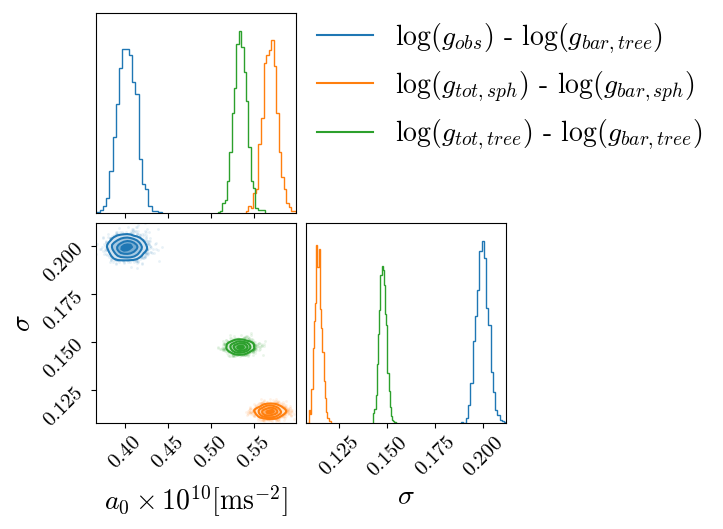

sigma_mixed: 0.19947007298469543
sigma_tot: 0.11404423415660858
sigma_pytree: 0.14763417840003967


In [ ]:
import matplotlib.lines as mlines
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size

sample_labels = ['$\log({g_{obs}})$ - $\log({g_{bar,tree}})$',
                '$\log({g_{tot,sph}})$ - $\log({g_{bar,sph}})$',
                '$\log({g_{tot,tree}})$ - $\log({g_{bar,tree}})$']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig = corner.corner(samples_array_mixed, labels = [r'$a_0 \times 10^{10}$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[0], smooth = 1)

fig = corner.corner(samples_array_tot, labels = [r'$a_0 \times 10^{10}$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[1], smooth = 1, fig = fig)

fig = corner.corner(samples_array, labels = [r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[2], smooth = 1, fig = fig)

plt.legend(handles=[
    mlines.Line2D([], [], color = colors[i], label=sample_labels[i])
    for i in range(3)], fontsize=20, frameon=False, loc = (0.,1.3)
)


plt.show()

print(f'sigma_mixed: {sigma_mixed}')
print(f'sigma_tot: {sigma_tot}')
print(f'sigma_pytree: {sigma_pytree}')

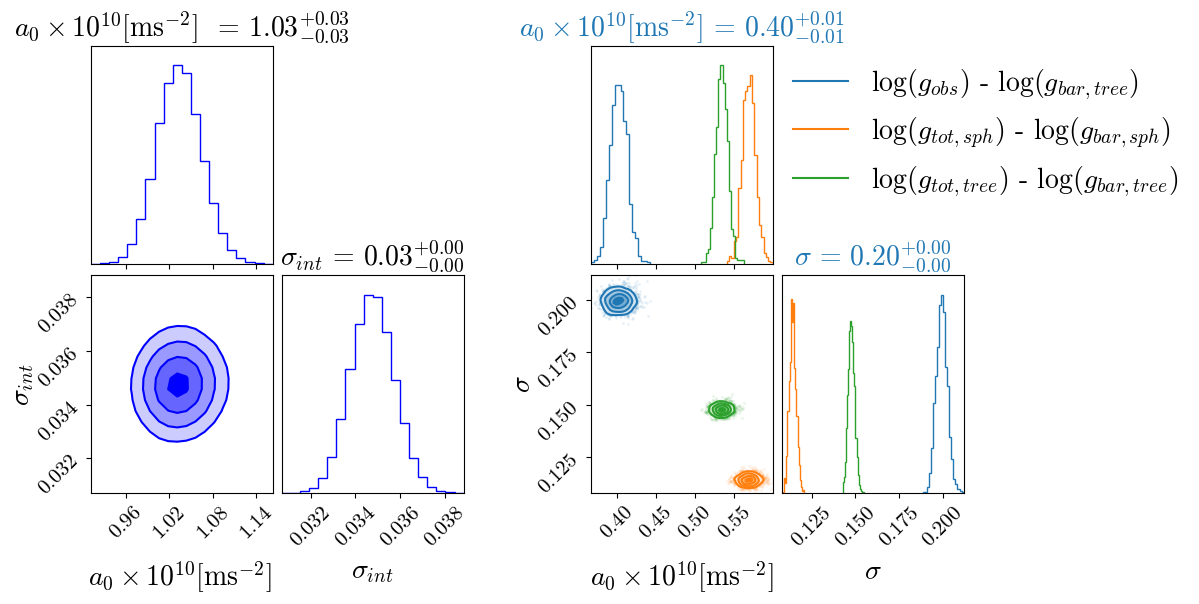

In [ ]:

import matplotlib.lines as mlines
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size


directory = '/mnt/users/darnej/MPhys/'

files = glob.glob(os.path.join(directory, '*.npy'))

samples = files[0]
labels = files[1]

labels = np.load(labels)

samples = np.load(samples)

a0_index = np.where(labels == 'a0')[0][0]

scatter_index = np.where(labels == 'scatter')[0][0]

a0 = samples[:, a0_index]

scatter = samples[:, scatter_index]

samples_SPARC = np.column_stack((a0, scatter))

fig = plt.figure(figsize=(10, 6))
subfigs = fig.subfigures(1, 2)


fig1 = corner.corner(samples_SPARC, 
                      labels=[r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$ ', '$\sigma_{int}$'],
                      show_titles=True,
                      title_kwargs={"fontsize": 20, 'color': 'black'}, 
                      label_kwargs={"fontsize": 20},
                      fill_contours=True,
                      color='blue',
                      plot_datapoints=False,
                      smooth = 1,
                      fig = subfigs[0])


sample_labels = ['$\log({g_{obs}})$ - $\log({g_{bar,tree}})$',
                '$\log({g_{tot,sph}})$ - $\log({g_{bar,sph}})$',
                '$\log({g_{tot,tree}})$ - $\log({g_{bar,tree}})$']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']



fig2 = corner.corner(samples_array_mixed, labels = [r'$a_0 \times 10^{10}[\mathrm{ms^{-2}}]$', '$\sigma$'], show_titles = True, title_kwargs={"fontsize": 20, "color": colors[0]}, label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[0], smooth = 1, fig = subfigs[1])

fig2 = corner.corner(samples_array_tot, labels = [r'$a_0 \times 10^{10}$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[1], smooth = 1, fig = subfigs[1])

fig2 = corner.corner(samples_array, labels = [r'$a_0 \times 10^{10} [\mathrm{ms^{-2}}]$', '$\sigma$'], label_kwargs={"fontsize": 20}, fill_contours=True, color=colors[2], smooth = 1, fig = subfigs[1])

plt.legend(handles=[
    mlines.Line2D([], [], color = colors[i], label=sample_labels[i])
    for i in range(3)], fontsize=20, frameon=False, loc = (0.,1.3)
)


plt.show()

In [ ]:

import numpy as np
from scipy.spatial.distance import mahalanobis

# Compute sample means (NOT medians)
mean_obs = np.mean(samples_array_mixed, axis=0)
mean_SPARC = np.mean(samples_SPARC, axis=0)

# Compute individual covariances
cov_obs = np.cov(samples_array_mixed, rowvar=False)
cov_SPARC = np.cov(samples_SPARC, rowvar=False)

# Pooled covariance = sum of covariances
cov_pooled = cov_obs + cov_SPARC

# Inverse of pooled covariance
inv_cov_pooled = np.linalg.pinv(cov_pooled)  # using pinv for safety

# Mahalanobis distance
dist = mahalanobis(mean_obs, mean_SPARC, inv_cov_pooled)

print('Mahalanobis distance:', dist)

Mahalanobis distance: 52.68003697433802


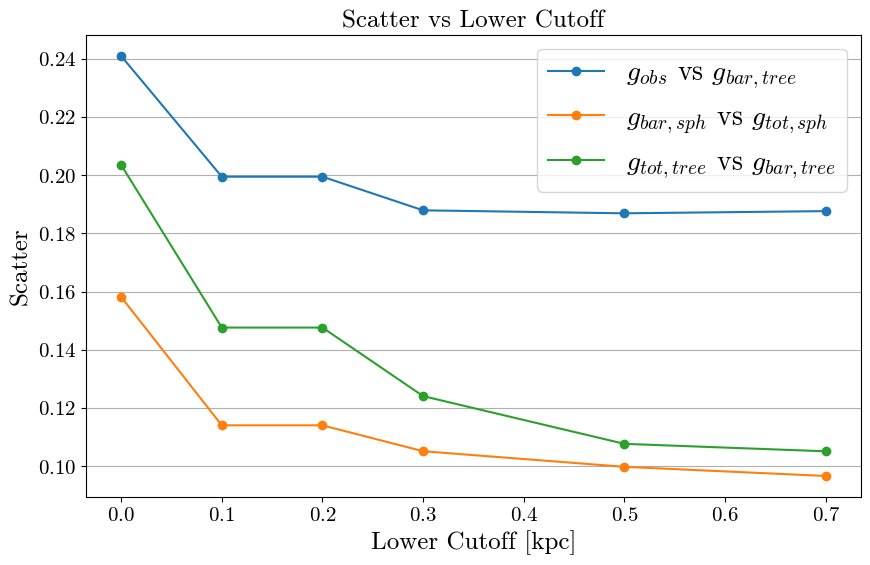

In [ ]:
#PLOTTING SCATTERS FOR DIFFERENT LOWER CUTOFF


Lower_cutoff = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]



mixed_scatter = [0.24096015095710754, 0.19947007298469543, 0.19947007298469543, 0.1879209727048874, 0.18689820170402527, 0.1876508891582489]
tot_sph_scatter = [0.15814882516860962, 0.11404423415660858, 0.11404423415660858, 0.1051531583070755, 0.09978727251291275, 0.09664586186408997]
tot_tree_scatter = [0.20354029536247253, 0.1476411521434784, 0.14763417840003967, 0.1240851879119873, 0.10768517851829529, 0.10512233525514603]


plt.figure(figsize=(10, 6))
plt.plot(Lower_cutoff, mixed_scatter, marker='o', label='$g_{obs}$ vs $g_{bar,tree}$')
plt.plot(Lower_cutoff, tot_sph_scatter, marker='o', label='$g_{bar,sph}$ vs $g_{tot,sph}$')
plt.plot(Lower_cutoff, tot_tree_scatter, marker='o', label='$g_{tot,tree}$ vs $g_{bar,tree}$')
plt.xlabel('Lower Cutoff [kpc]', fontsize=18)
plt.ylabel('Scatter', fontsize=18)
plt.title('Scatter vs Lower Cutoff', fontsize=18)
plt.legend(prop={'size': 20}, frameon = True)
plt.grid(axis = 'y')
plt.show()
